# Sentiment Classification Project

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load data

In [63]:
train_full = pd.read_csv("data/train.csv")
print(train_full[5:10])
print("\n\n")
print("-" * 50)
print("\n\n")
print(train_full["sentence"].iloc[6])

   id                                           sentence  label
5   5  Jürgen Boos\r\n\r\nLäuft nicht auf allen meine...      2
6   6  I hope they get it togather.\r\n\r\nThe design...      1
7   7  Schön aber naja..\r\n\r\nSitzt ein bisschen we...      2
8   8  Angenehm zu tragen.\r\n\r\nSehr praktisch. Lei...      3
9   9  Eh - for me, anyway\r\n\r\nFeel was ok-ish, di...      1



--------------------------------------------------



I hope they get it togather.

The design was good. The bad part it did not preform, I used an extra att. still not good on SW AIR bands. Will buy another brand.


# Build Validation Set
We use 90% of the reviews for training, and the remaining 10% for validation

In [3]:
train_df, val_df = train_test_split(
        train_full, test_size=0.1, stratify=train_full["label"], random_state=42
)

## Maybe follow the pipeline: pre-process, embed, represent, classify

# Preprocessing

TODO make this more elaborate (to lower(?), stopwords, language?, tokenize with BPE?)

In [65]:
from gensim.utils import simple_preprocess

tokenized_train = [simple_preprocess(t) for t in train_df['sentence']]
tokenized_val = [simple_preprocess(t) for t in val_df['sentence']]
tokenized = tokenized_train + tokenized_val

# Embed: Word2Vec Embeddings

Word2vec. then pca/viz

In [66]:
from gensim.models import Word2Vec

##DONE train a word2vec model on this dataset which appear at least 10 times in the corpus
# using params from kaggle 
w2v_model = Word2Vec(min_count=20,
                     window=2,
                     vector_size=150,
                     sample=6e-5, 
                     alpha=0.03, 
                     min_alpha=0.0007, 
                     negative=20)

w2v_model.build_vocab(tokenized, progress_per=10000)

w2v_model.train(tokenized, total_examples=w2v_model.corpus_count, epochs=15, report_delay=1)

(60496478, 135607365)

In [12]:
w2v_model.wv

Visualization

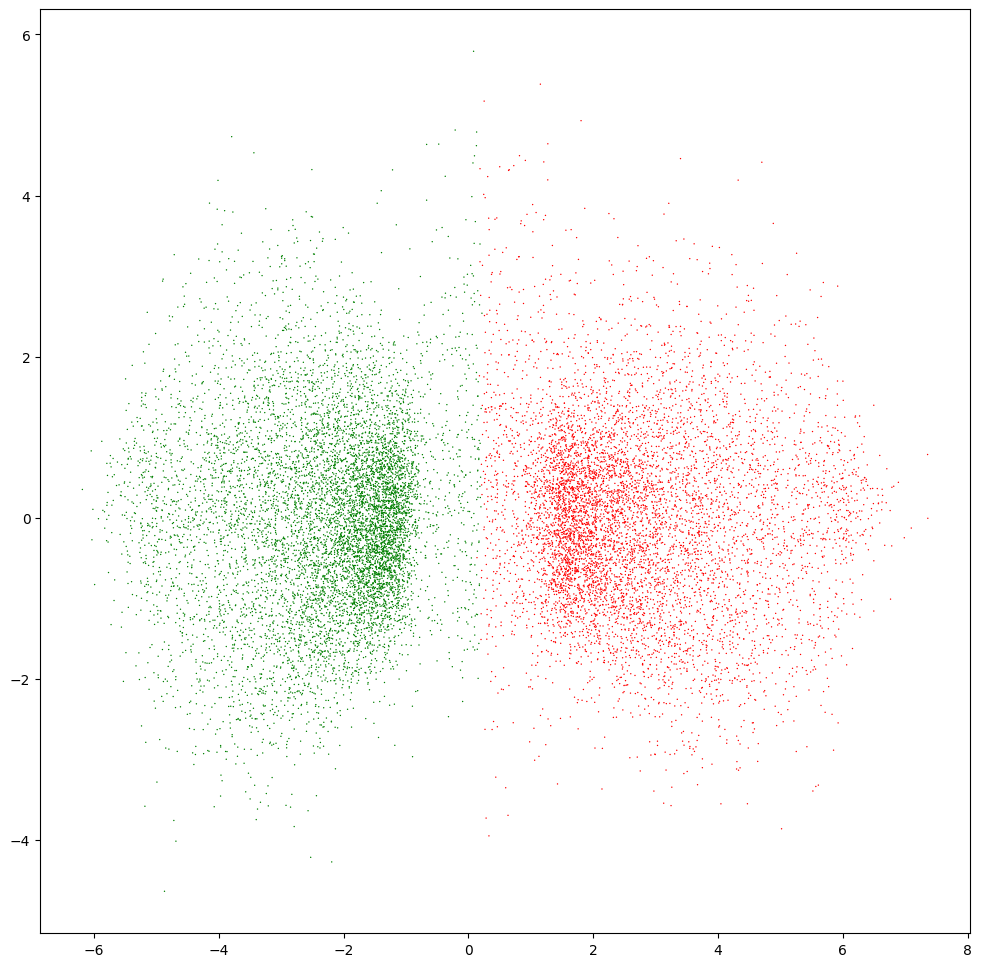

In [13]:
pca = PCA(n_components=2)
wrds = list(w2v_model.wv.index_to_key)
vecs = w2v_model.wv.vectors
plot_vecs = pca.fit_transform(vecs)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(vecs)

# 2. Setup colors - we'll map 0 to 'red' and 1 to 'green'
colors = ['red' if c == 0 else 'green' for c in clusters]

plt.figure(figsize=(12,12))
plt.scatter(plot_vecs[:, 0], plot_vecs[:, 1], edgecolors='k', c=colors, s=1, linewidth=0)

# for i, word in enumerate(wrds[:50]):
#     plt.annotate(word, xy=(plot_vecs[i, 0], plot_vecs[i, 1]))

In [22]:
# english! 
words_cluster = [wrds[i] for i in range(len(clusters)) if clusters[i] == 0]
tokenized_filtered = [[t for t in doc if t in words_cluster] for doc in tokenized]

Verdict -- the concept of language is very much in word2vec embeddings too! 

# Represent: TF-IDF weighting 

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Initialize and fit TF-IDF
tfidf = TfidfVectorizer(analyzer=lambda x: x) # Use our already tokenized 'sentences'
tfidf.fit(tokenized)

# Create a dictionary for fast lookup: {word: idf_score}
# Words not in the TF-IDF vocab will get the max IDF score (or 0)
max_idf = max(tfidf.idf_)
word2weight = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

In [70]:
def get_doc_vector(tokens, model, word2weight):
    # Filter tokens: must be in W2V vocab and TF-IDF vocab
    valid_tokens = [t for t in tokens if t in model.wv.key_to_index and t in word2weight]
    
    if not valid_tokens:
        print("Uh oh")
        return np.zeros(model.vector_size)

    # Get vectors and their corresponding weights
    vectors = np.array([model.wv[t] for t in valid_tokens])
    weights = np.array([word2weight[t] for t in valid_tokens]).reshape(-1, 1)

    # Calculate weighted average: (Vectors * Weights) / Sum of Weights
    weighted_sum = np.sum(vectors * weights, axis=0)
    return weighted_sum / np.sum(weights)

# Apply to all your documents
X_mlp = np.array([get_doc_vector(doc, w2v_model, word2weight) for doc in tokenized])

Uh oh
Uh oh


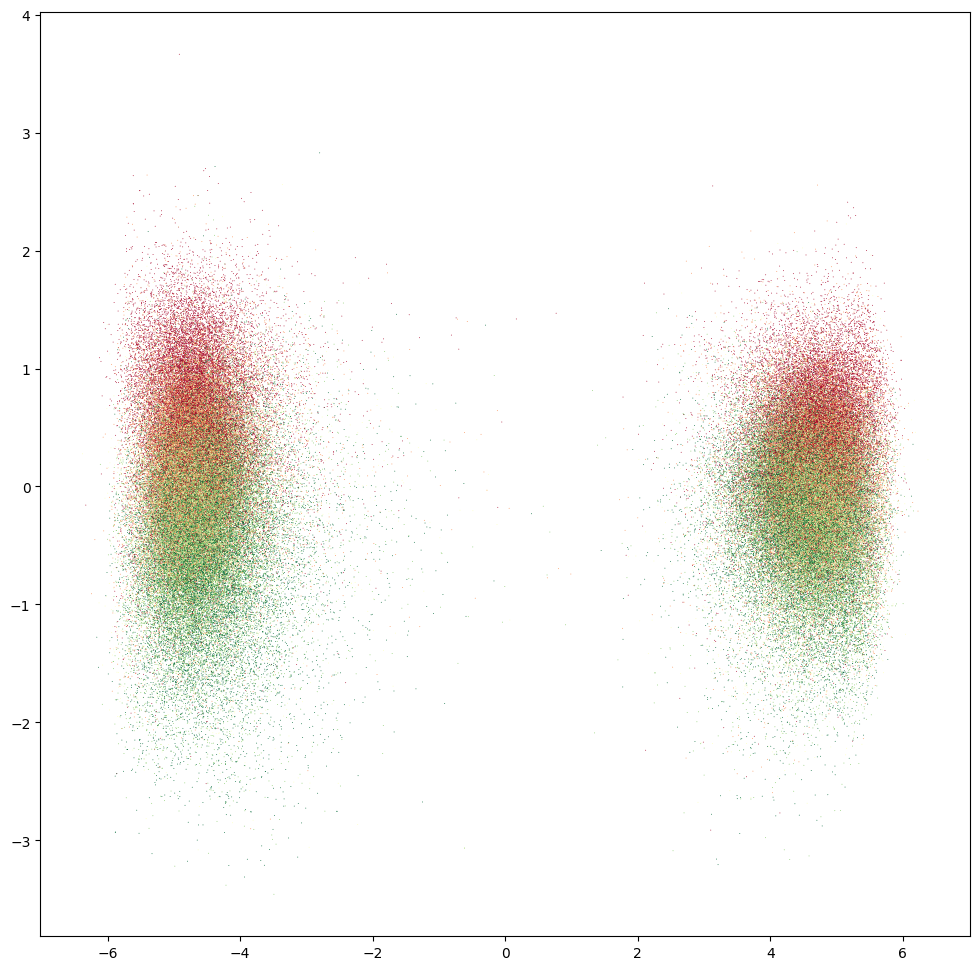

In [140]:
pca = PCA(n_components=2)
mlp_plot_vecs = pca.fit_transform(X_mlp)
y_train = train_df['label'].tolist() + val_df['label'].tolist()

# mask = np.array(y_train) == 4

# filtered_vecs = mlp_plot_vecs[mask]
# filtered_y = np.array(y_train)[mask]

plt.figure(figsize=(12,12))
plt.scatter(mlp_plot_vecs[:, 0], mlp_plot_vecs[:, 1], edgecolors='k', c=y_train, cmap='RdYlGn', s=0.4, linewidths=0)
# plt.figure(figsize=(12,12))
# plt.scatter(filtered_vecs[:, 0], filtered_vecs[:, 1], edgecolors='k', c=filtered_y, cmap='RdYlGn', s=0.1)

In [ ]:
word_to_cluster = {wrds[i]: clusters[i] for i in range(len(wrds))}

def get_sentence_cluster(tokens):
    cluster_counts = [0, 0]
    for t in tokens:
        if t in word_to_cluster:
            cluster_counts[word_to_cluster[t]] += 1
    if cluster_counts[0] > cluster_counts[1]:
        return 0
    elif cluster_counts[1] > cluster_counts[0]:
        return 1
    else:
        return -1  # tie or no words

wanted_cluster = 0

mask_train = [get_sentence_cluster(t) == wanted_cluster for t in tokenized_train]
mask_val = [get_sentence_cluster(t) == wanted_cluster for t in tokenized_val]

train_df = train_df[mask_train]
val_df = val_df[mask_val]

tokenized_train = [t for t, m in zip(tokenized_train, mask_train) if m]
tokenized_val = [t for t, m in zip(tokenized_val, mask_val) if m]

print(f"Filtered train size: {len(train_df)}")
print(f"Filtered val size: {len(val_df)}")

Finding: this representation's 2 principal components are 1) language and 2) the sentiment!

In [75]:
n = 10000
print(tokenized[n])
print(y_train[n])

['not', 'impressed', 'when', 'received', 'my', 'shipment', 'put', 'batteries', 'into', 'this', 'and', 'the', 'display', 'lights', 'up', 'but', 'nothing', 'responds', 'to', 'anything', 'except', 'the', 'shake', 'function', 'the', 'instructions', 'require', 'little', 'more', 'than', 'lighter', 'because', 'they', 'are', 'absolutely', 'worthless', 'if', 'you', 're', 'able', 'to', 'get', 'magnification', 'enough', 'you', 'realize', 'nothing', 'is', 'spelled', 'correctly', 'the', 'grammar', 'is', 'no', 'where', 'near', 'correct', 'so', 'they', 'basically', 'are', 'completely', 'useless', 'because', 'it', 'completely', 'illegible', 'can', 'tell', 'it', 'written', 'to', 'be', 'map', 'of', 'functionality', 'but', 'like', 'said', 'nothing', 'is', 'legible', 'in', 'any', 'way', 'shape', 'nor', 'form', 'so', 'they', 'are', 'worthless', 'now', 'back', 'to', 'my', 'original', 'comment', 'nothing', 'seems', 'to', 'be', 'responding', 'to', 'anything', 'at', 'all', 'except', 'the', 'shake', 'supposedly

# Classify: MLP

In [144]:
from sklearn.preprocessing import StandardScaler

y_train = train_df['label'].tolist()
y_val = val_df['label'].tolist()

val_ind = len(y_train)

X_train = X_mlp[:val_ind]
X_val = X_mlp[val_ind:]

from sklearn.preprocessing import normalize

X_train = normalize(X_train)
X_val = normalize(X_val)

# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)

In [145]:
from sklearn.neural_network import MLPClassifier

# Simple MLP setup
mlp = MLPClassifier(
    hidden_layer_sizes=(75, 25), 
    max_iter=100, 
    early_stopping=True,
    validation_fraction=0.05, 
    activation='relu', 
    solver='adam', 
    random_state=42
)

mlp.fit(X_train, y_train)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(75, 25), max_iter=100,
              random_state=42, validation_fraction=0.05)

In [130]:
from sklearn.svm import LinearSVC

# 1. Initialize LinearSVC
# 'multi_class=ovr' (One-vs-Rest) handles your 5 classes automatically
svm = LinearSVC(
    C=1.0,               # Regularization; lower values (e.g., 0.1) prevent overfitting
    max_iter=1000, 
    random_state=42,
    dual=False           # Use False when n_samples > n_features for better speed
)

model.fit(X_train, y_train)

LogisticRegression()

In [137]:
# Logistic Regression Classifier, C: Inverse of regularization strength , max_iter: Maximum number of training iterations
model = LogisticRegression(C=1.0, max_iter=100)
model.fit(X_train, y_train)

LogisticRegression()

In [146]:
from sklearn.metrics import mean_absolute_error

# 1. Generate predictions
Y_train_pred = mlp.predict(X_train)
Y_val_pred = mlp.predict(X_val)

# 2. Calculate Training Metrics
mae_train = mean_absolute_error(y_train, Y_train_pred)
score_train = 1.0 - (mae_train / 4.0)
accuracy_train = np.mean(y_train == Y_train_pred)

# 3. Calculate Validation Metrics
mae_val = mean_absolute_error(y_val, Y_val_pred)
score_val = 1.0 - (mae_val / 4.0)
accuracy_val = mlp.score(X_val, y_val) 

# 4. Clean Combined Output
print(f"Training Score: {score_train:.4f}, MAE: {mae_train:.4f}, Accuracy: {accuracy_train:.4f}")
print(f"Validation Score: {score_val:.4f}, MAE: {mae_val:.4f}, Accuracy: {accuracy_val:.4f}")

Training Score: 0.8552, MAE: 0.5791, Accuracy: 0.5521
Validation Score: 0.8510, MAE: 0.5960, Accuracy: 0.5415


# Bag-of-words + Logistic Regression

In [92]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# We only use words from cluster 0
words_cluster_0 = [wrds[i] for i in range(len(clusters)) if clusters[i] == 0]

vectorizer = CountVectorizer(ngram_range=(1, 1), vocabulary=words_cluster_0)

In [94]:
# Important: Fit ONLY on training data
X_train = vectorizer.fit_transform(train_df["sentence"])
X_val = vectorizer.transform(val_df["sentence"])

Y_train = train_df["label"]
Y_val = val_df["label"]

In [95]:
X_train

<226800x10000 sparse matrix of type '<class 'numpy.int64'>'
	with 8225774 stored elements in Compressed Sparse Row format>

In [96]:
print(X_train[2])

  (0, 7119)	3
  (0, 52)	6
  (0, 2552)	3
  (0, 5790)	1
  (0, 2342)	1
  (0, 71)	1
  (0, 7063)	1
  (0, 5368)	3
  (0, 7056)	1
  (0, 912)	1
  (0, 6421)	1
  (0, 1950)	6
  (0, 3830)	1
  (0, 5082)	1
  (0, 9084)	3
  (0, 760)	2
  (0, 2365)	1
  (0, 2277)	1
  (0, 8698)	3
  (0, 7068)	1
  (0, 2340)	1
  (0, 639)	4
  (0, 1832)	3
  (0, 3852)	1
  (0, 5982)	1
  :	:
  (0, 4242)	1
  (0, 321)	1
  (0, 7298)	1
  (0, 2348)	1
  (0, 3499)	1
  (0, 3995)	1
  (0, 2580)	1
  (0, 4261)	1
  (0, 8795)	1
  (0, 9100)	1
  (0, 57)	2
  (0, 649)	1
  (0, 9875)	1
  (0, 908)	1
  (0, 5352)	1
  (0, 5751)	1
  (0, 8764)	1
  (0, 5370)	1
  (0, 726)	1
  (0, 4252)	1
  (0, 1732)	1
  (0, 2056)	1
  (0, 4546)	1
  (0, 641)	1
  (0, 308)	1


Now we train a logistic regression classifier...

In [97]:
from sklearn.linear_model import LogisticRegression

In [98]:
# Logistic Regression Classifier, C: Inverse of regularization strength , max_iter: Maximum number of training iterations
model = LogisticRegression(C=1.0, max_iter=100)
model.fit(X_train, Y_train)

LogisticRegression()

# Evaluate model

In [99]:
Y_train_pred = model.predict(X_train)
Y_val_pred = model.predict(X_val)

In [100]:
from sklearn.metrics import mean_absolute_error

In [101]:
# score on training set
mae_train = mean_absolute_error(Y_train, Y_train_pred)
score_train = 1.0 - (mae_train / 4.0)
accuracy_train = np.mean(Y_train == Y_train_pred)

# score on validation set
mae_val = mean_absolute_error(Y_val, Y_val_pred)
score_val = 1.0 - (mae_val / 4.0)
accuracy_val = np.mean(Y_val == Y_val_pred)
    

print(f"Training Score: {score_train:.4f}, MAE: {mae_train:.4f}, Accuracy: {accuracy_train:.4f}")
print(f"Validation Score: {score_val:.4f}, MAE: {mae_val:.4f}, Accuracy: {accuracy_val:.4f}")

Training Score: 0.8880, MAE: 0.4481, Accuracy: 0.6441
Validation Score: 0.8701, MAE: 0.5196, Accuracy: 0.5819


# Make test submission

In [ ]:
test_df = pd.read_csv("data/test.csv")
X_test = vectorizer.transform(test_df["sentence"])

In [ ]:
submit_preds = model.predict(X_test)
submission = pd.DataFrame({
    "id": test_df["id"],
    "label": submit_preds
})

submission_path = "submissions/submission.csv"
submission.to_csv(submission_path, index=False)

# Model Interpretation

In [ ]:
# Top N most Important Words & Word Pairs per Output Class (Pos, Neutral, Negative)
feature_names = vectorizer.get_feature_names_out() # get names of all tokens from vectorizer
coefs = model.coef_  # Weights per Feature for each Output Class; Shape: (Num_Output_Classes, Num_Features)

# Get Top_n Features by Weight for each Class
def get_top_features(class_index, top_n=10):
    class_coef = coefs[class_index]
    top_indices = np.argsort(class_coef)[-top_n:]
    return [feature_names[i] for i in reversed(top_indices)]

print("Top words & bigrams for 1 stars:", get_top_features(0))
print("Top words & bigrams for 2 star:", get_top_features(1))
print("Top words & bigrams for 3 stars:", get_top_features(2))
print("Top words & bigrams for 4 stars:", get_top_features(3))
print("Top words & bigrams for 5 stars:", get_top_features(4))

In [ ]:
# Confusion Matrix - Negative, Neutral, Positive
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(Y_val,Y_val_pred, labels=[0,1,2,3,4])
print(conf_matrix)

In [ ]:
results_df = val_df.copy()
results_df['predicted_label'] = Y_val_pred

results_df['diff'] = (results_df['label'] - results_df['predicted_label']).abs()
very_off = results_df[results_df['diff'] >= 3].sort_values(by='diff', ascending=False)

for i, row in very_off.head(10).iterrows():
    print(f"--- Review Snippet ---")
    print(f"{row['sentence'][:300]}...") # Increased to 300 to see more context
    print(f"Actual: {row['label']} | Predicted: {row['predicted_label']}")
    print("-" * 30 + "\n")

# Experiment 1: Preprocessing Strategy Comparison

Compare four tokenization approaches feeding the same pipeline: **Word2Vec → TF-IDF weighted average → MLP (early stopping)**.

| Strategy | Idea |
|---|---|
| **A** | `gensim.simple_preprocess` + TF-IDF — existing baseline |
| **A'** | same tokens, uniform weighting — TF-IDF ablation |
| **B** | WordPiece subwords (mBERT) — shared subword reps across morphological variants; better for German compounds |
| **C** | `langdetect` + NLTK stopwords + Snowball stemmer per language — language-appropriate noise removal |

Each strategy re-trains its own Word2Vec from scratch on the same 90/10 split so results are directly comparable.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Experiment 1: Preprocessing Strategy Comparison
# Same pipeline throughout: tokenize → Word2Vec → TF-IDF weighted avg → MLP
#
# Strategy A  : gensim simple_preprocess              (existing baseline)
# Strategy A' : simple_preprocess, no TF-IDF          (TF-IDF ablation)
# Strategy B  : WordPiece subwords (mBERT tokenizer)  (subword units)
# Strategy C  : Language-aware NLTK + Snowball         (per-lang stopwords + stemming)
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import normalize
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# ── 0. Fresh data (independent of earlier cells) ───────────────────────────────
_full1 = pd.read_csv("data/train.csv")
_tr1, _val1 = train_test_split(_full1, test_size=0.1, stratify=_full1["label"], random_state=42)
_y_tr1  = _tr1['label'].tolist()
_y_val1 = _val1['label'].tolist()
print(f"Train: {len(_tr1):,}  Val: {len(_val1):,}\n")

# ── 1. Pipeline helpers ────────────────────────────────────────────────────────
def _build_vecs1(tok_tr, tok_val, vector_size=150, min_count=10,
                 window=2, epochs=15, use_tfidf=True):
    """W2V trained on tr+val, optional TF-IDF weighting, L2-normalised output."""
    all_tok = tok_tr + tok_val
    wm = Word2Vec(min_count=min_count, window=window, vector_size=vector_size,
                  sample=6e-5, alpha=0.03, min_alpha=0.0007, negative=20)
    wm.build_vocab(all_tok)
    wm.train(all_tok, total_examples=wm.corpus_count, epochs=epochs, report_delay=1)

    if use_tfidf:
        tfidf = TfidfVectorizer(analyzer=lambda x: x)
        tfidf.fit(all_tok)
        w2w = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
        get_w = lambda t: w2w.get(t, 1.0)
    else:
        get_w = lambda t: 1.0  # uniform: plain average

    def dv(tokens):
        valid = [t for t in tokens if t in wm.wv.key_to_index]
        if not valid:
            return np.zeros(vector_size)
        V = np.array([wm.wv[t] for t in valid])
        W = np.array([get_w(t) for t in valid]).reshape(-1, 1)
        return np.sum(V * W, axis=0) / np.sum(W)

    return (normalize(np.array([dv(d) for d in tok_tr])),
            normalize(np.array([dv(d) for d in tok_val])))

def _run_mlp1(Xtr, Xval, ytr, yval, name):
    mlp = MLPClassifier(
        hidden_layer_sizes=(75, 25), 
        max_iter=100, 
        early_stopping=True,
        validation_fraction=0.05, 
        activation='relu', 
        solver='adam', 
        random_state=42
    )
    mlp.fit(Xtr, ytr)
    mae_val = mean_absolute_error(yval, mlp.predict(Xval))
    mae_tr  = mean_absolute_error(ytr,  mlp.predict(Xtr))
    acc_val = np.mean(np.array(yval) == mlp.predict(Xval))
    print(f"  [{name:52s}]  val_MAE={mae_val:.4f}  score={1-mae_val/4:.4f}"
          f"  acc={acc_val:.4f}  ep={mlp.n_iter_}")
    return dict(name=name, mae_val=mae_val, score_val=1-mae_val/4,
                mae_tr=mae_tr, acc_val=acc_val, epochs=mlp.n_iter_)

exp1_results = []

# ── A: Baseline ────────────────────────────────────────────────────────────────
print("── A: Baseline (simple_preprocess + TF-IDF) ──")
_tok_A_tr  = [simple_preprocess(s) for s in _tr1['sentence']]
_tok_A_val = [simple_preprocess(s) for s in _val1['sentence']]
Xtr, Xvl = _build_vecs1(_tok_A_tr, _tok_A_val)
exp1_results.append(_run_mlp1(Xtr, Xvl, _y_tr1, _y_val1, "A: simple_preprocess + TF-IDF"))

# ── A': TF-IDF ablation (same tokens, uniform weighting) ──────────────────────
print("\n── A': Ablation — simple_preprocess, no TF-IDF (plain average) ──")
Xtr, Xvl = _build_vecs1(_tok_A_tr, _tok_A_val, use_tfidf=False)
exp1_results.append(_run_mlp1(Xtr, Xvl, _y_tr1, _y_val1, "A': simple_preprocess, no TF-IDF (avg)"))

# ── B: WordPiece subwords (bert-base-multilingual-cased) ──────────────────────
# Subword units share representations across inflected forms.
# Handles German compound words that simple_preprocess treats as single OOV tokens.
print("\n── B: WordPiece (mBERT multilingual tokenizer) ──")
from transformers import BertTokenizer
_wp = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

_tok_B_tr  = [_wp.tokenize(s.lower()) for s in _tr1['sentence']]
_tok_B_val = [_wp.tokenize(s.lower()) for s in _val1['sentence']]
Xtr, Xvl = _build_vecs1(_tok_B_tr, _tok_B_val, min_count=5)
exp1_results.append(_run_mlp1(Xtr, Xvl, _y_tr1, _y_val1, "B: WordPiece (mBERT subwords, min_count=5)"))

# ── C: Language-aware (langdetect + NLTK stopwords + SnowballStemmer) ─────────
# Detects EN vs DE per review, removes that language's stopwords,
# then stems to root form (e.g. "spielte" → "spiel", "played" → "play").
print("\n── C: Language-aware (langdetect + stopwords + stemming) ──")
try:
    from langdetect import detect, LangDetectException
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'langdetect'])
    from langdetect import detect, LangDetectException

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords as _nltk_sw
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize as _wt

_en_stops = set(_nltk_sw.words('english'))
_de_stops = set(_nltk_sw.words('german'))
_en_stem  = SnowballStemmer('english')
_de_stem  = SnowballStemmer('german')

def _lang_tok(text):
    try:    lang = detect(text)
    except: lang = 'en'
    tokens = [t for t in _wt(text.lower()) if t.isalpha() and len(t) > 2]
    if lang == 'de':
        return [_de_stem.stem(t) for t in tokens if t not in _de_stops]
    return [_en_stem.stem(t) for t in tokens if t not in _en_stops]

print("  Tokenising train (~1-2 min)...")
_tok_C_tr  = [_lang_tok(s) for s in _tr1['sentence']]
print("  Tokenising val...")
_tok_C_val = [_lang_tok(s) for s in _val1['sentence']]
Xtr, Xvl = _build_vecs1(_tok_C_tr, _tok_C_val)
exp1_results.append(_run_mlp1(Xtr, Xvl, _y_tr1, _y_val1, "C: lang-aware (stopwords + stemming)"))

# ── Summary ────────────────────────────────────────────────────────────────────
print("\n\n══ Preprocessing Strategy Comparison ══")
display(pd.DataFrame([{
    'Strategy': r['name'],
    'Val MAE':            f"{r['mae_val']:.4f}",
    'Val Score (1-MAE/4)':f"{r['score_val']:.4f}",
    'Val Acc':            f"{r['acc_val']:.4f}",
    'Train MAE':          f"{r['mae_tr']:.4f}",
    'Epochs (early stop)':r['epochs'],
} for r in exp1_results]))

Train: 226,800  Val: 25,200

── A: Baseline (simple_preprocess + TF-IDF) ──
  [A: simple_preprocess + TF-IDF                       ]  val_MAE=0.6017  score=0.8496  acc=0.5391  ep=37

── A': Ablation — simple_preprocess, no TF-IDF (plain average) ──
  [A': simple_preprocess, no TF-IDF (avg)              ]  val_MAE=0.5548  score=0.8613  acc=0.5573  ep=53

── B: WordPiece (mBERT multilingual tokenizer) ──


OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\Users\lucas\miniconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

# Experiment 2: Language-Separated MLPs

Use k-means word clusters (EN vs DE) to train one specialist MLP per language.  
At inference, each sentence is routed to its language's model via majority-vote over token clusters.  
Compare against a single combined model on the full validation set.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Experiment 2: Language-Separated MLPs
#
# The k-means above cleanly separates EN/DE words in W2V space.
# Here we exploit that to train one MLP per language, then route
# each val sample to its specialist at inference time.
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import normalize
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# ── 0. Fresh data ──────────────────────────────────────────────────────────────
_full2 = pd.read_csv("data/train.csv")
_tr2, _val2 = train_test_split(_full2, test_size=0.1, stratify=_full2["label"], random_state=42)
_tok_tr2  = [simple_preprocess(s) for s in _tr2['sentence']]
_tok_val2 = [simple_preprocess(s) for s in _val2['sentence']]
_y_tr2  = _tr2['label'].tolist()
_y_val2 = _val2['label'].tolist()

# ── 1. W2V + k-means for language assignment ───────────────────────────────────
print("Training Word2Vec for language clustering...")
_all2 = _tok_tr2 + _tok_val2
_wm_km = Word2Vec(min_count=20, window=2, vector_size=150,
                  sample=6e-5, alpha=0.03, min_alpha=0.0007, negative=20)
_wm_km.build_vocab(_all2)
_wm_km.train(_all2, total_examples=_wm_km.corpus_count, epochs=15, report_delay=1)

_wrds_km = list(_wm_km.wv.index_to_key)
_km2     = KMeans(n_clusters=2, random_state=42, n_init=10)
_clust2  = _km2.fit_predict(_wm_km.wv.vectors)
_w2c2    = {_wrds_km[i]: _clust2[i] for i in range(len(_wrds_km))}

# Identify English cluster from reliable function words
_en_c = next((_w2c2[w] for w in ['the', 'and', 'this', 'was', 'is'] if w in _w2c2), 0)
print(f"English cluster: {_en_c}  |  sample words: "
      f"{[w for w in ['the','and','good','great','product'] if _w2c2.get(w)==_en_c][:5]}")

def _assign_lang(tokens):
    counts = [0, 0]
    for t in tokens:
        if t in _w2c2:
            counts[_w2c2[t]] += 1
    return 'en' if counts[_en_c] >= counts[1 - _en_c] else 'de'

_tr_langs2  = [_assign_lang(t) for t in _tok_tr2]
_val_langs2 = [_assign_lang(t) for t in _tok_val2]
print(f"\nTrain → EN: {_tr_langs2.count('en'):,}  DE: {_tr_langs2.count('de'):,}")
print(f"Val   → EN: {_val_langs2.count('en'):,}  DE: {_val_langs2.count('de'):,}")

# ── 2. Helpers ─────────────────────────────────────────────────────────────────
def _make_vecs2(tok_tr, tok_val, min_count=10, vector_size=150):
    all_tok = tok_tr + tok_val
    wm = Word2Vec(min_count=min_count, window=2, vector_size=vector_size,
                  sample=6e-5, alpha=0.03, min_alpha=0.0007, negative=20)
    wm.build_vocab(all_tok)
    wm.train(all_tok, total_examples=wm.corpus_count, epochs=15, report_delay=1)
    tfidf = TfidfVectorizer(analyzer=lambda x: x)
    tfidf.fit(all_tok)
    w2w = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

    def dv(tokens):
        valid = [t for t in tokens if t in wm.wv.key_to_index and t in w2w]
        if not valid:
            return np.zeros(vector_size)
        V = np.array([wm.wv[t] for t in valid])
        W = np.array([w2w[t] for t in valid]).reshape(-1, 1)
        return np.sum(V * W, axis=0) / np.sum(W)

    Xtr  = normalize(np.array([dv(d) for d in tok_tr]))
    Xval = normalize(np.array([dv(d) for d in tok_val]))
    return Xtr, Xval, wm, w2w

def _fit_mlp2(Xtr, Xval, ytr, yval, name):
    mlp = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), max_iter=400,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=25, activation='relu', solver='adam',
        learning_rate_init=1e-3, random_state=42,
    )
    mlp.fit(Xtr, ytr)
    mae_val = mean_absolute_error(yval, mlp.predict(Xval))
    acc_val = np.mean(np.array(yval) == mlp.predict(Xval))
    print(f"  [{name:35s}]  val_MAE={mae_val:.4f}  score={1-mae_val/4:.4f}"
          f"  acc={acc_val:.4f}  ep={mlp.n_iter_}")
    return mlp, mae_val, acc_val

# ── 3a. Combined baseline ──────────────────────────────────────────────────────
print("\n── Combined single MLP (baseline) ──")
Xtr_c, Xval_c, _, _ = _make_vecs2(_tok_tr2, _tok_val2)
_mlp_c, _mae_c, _acc_c = _fit_mlp2(Xtr_c, Xval_c, _y_tr2, _y_val2, "Combined (no split)")

# ── 3b. English MLP ────────────────────────────────────────────────────────────
print("\n── English-only MLP ──")
_en_tr_m  = np.array(_tr_langs2)  == 'en'
_en_val_m = np.array(_val_langs2) == 'en'
tok_en_tr  = [t for t, m in zip(_tok_tr2,  _en_tr_m)  if m]
tok_en_val = [t for t, m in zip(_tok_val2, _en_val_m) if m]
y_en_tr  = _tr2[_en_tr_m]['label'].tolist()
y_en_val = _val2[_en_val_m]['label'].tolist()

Xtr_en, Xval_en, _wm_en, _w2w_en = _make_vecs2(tok_en_tr, tok_en_val)
_mlp_en, _mae_en, _acc_en = _fit_mlp2(Xtr_en, Xval_en, y_en_tr, y_en_val, "English-only")

# ── 3c. German MLP ─────────────────────────────────────────────────────────────
print("\n── German-only MLP ──")
_de_tr_m  = ~_en_tr_m
_de_val_m = ~_en_val_m
tok_de_tr  = [t for t, m in zip(_tok_tr2,  _de_tr_m)  if m]
tok_de_val = [t for t, m in zip(_tok_val2, _de_val_m) if m]
y_de_tr  = _tr2[_de_tr_m]['label'].tolist()
y_de_val = _val2[_de_val_m]['label'].tolist()

Xtr_de, Xval_de, _wm_de, _w2w_de = _make_vecs2(tok_de_tr, tok_de_val)
_mlp_de, _mae_de, _acc_de = _fit_mlp2(Xtr_de, Xval_de, y_de_tr, y_de_val, "German-only")

# ── 4. Routed evaluation on the full val set ───────────────────────────────────
# Each val sample is embedded using its language's W2V+TF-IDF model,
# then predicted by the matching specialist MLP.
print("\n── Routed inference on full val set ──")

def _dv_ext(tokens, wm, w2w, dim=150):
    valid = [t for t in tokens if t in wm.wv.key_to_index and t in w2w]
    if not valid:
        return np.zeros(dim)
    V = np.array([wm.wv[t] for t in valid])
    W = np.array([w2w[t] for t in valid]).reshape(-1, 1)
    return np.sum(V * W, axis=0) / np.sum(W)

Xval_via_en = normalize(np.array([_dv_ext(t, _wm_en, _w2w_en) for t in _tok_val2]))
Xval_via_de = normalize(np.array([_dv_ext(t, _wm_de, _w2w_de) for t in _tok_val2]))

_y_routed = [
    _mlp_en.predict(Xval_via_en[i:i+1])[0] if lang == 'en'
    else _mlp_de.predict(Xval_via_de[i:i+1])[0]
    for i, lang in enumerate(_val_langs2)
]
_mae_routed = mean_absolute_error(_y_val2, _y_routed)
_acc_routed = np.mean(np.array(_y_val2) == np.array(_y_routed))
print(f"  [{'Routed EN+DE':35s}]  val_MAE={_mae_routed:.4f}  score={1-_mae_routed/4:.4f}"
      f"  acc={_acc_routed:.4f}")

# ── 5. Summary table ───────────────────────────────────────────────────────────
print("\n\n══ Language Separation Results ══")
display(pd.DataFrame([
    {'Model': 'EN-only MLP (EN val only)', 'N val': int(_en_val_m.sum()),
     'Val MAE': f"{_mae_en:.4f}", 'Val Score': f"{1-_mae_en/4:.4f}", 'Val Acc': f"{_acc_en:.4f}"},
    {'Model': 'DE-only MLP (DE val only)', 'N val': int(_de_val_m.sum()),
     'Val MAE': f"{_mae_de:.4f}", 'Val Score': f"{1-_mae_de/4:.4f}", 'Val Acc': f"{_acc_de:.4f}"},
    {'Model': 'Routed EN+DE (full val)',   'N val': len(_y_val2),
     'Val MAE': f"{_mae_routed:.4f}", 'Val Score': f"{1-_mae_routed/4:.4f}", 'Val Acc': f"{_acc_routed:.4f}"},
    {'Model': 'Combined single MLP',       'N val': len(_y_val2),
     'Val MAE': f"{_mae_c:.4f}", 'Val Score': f"{1-_mae_c/4:.4f}", 'Val Acc': f"{_acc_c:.4f}"},
]))